## Example 1: Degenerate Markov Chain

#### Overview

We explore a case where **different parameterizations lead to the same stochastic dynamics**. Both systems are **conservative**:

$$X_1 + X_2 = \text{constant}$$

For a total count of 2, the systems produce **identical stochastic transitions**.

---

### System 1: Simple Reversible
$$
X_1 \xrightarrow{k_1 = 1} X_2, \quad X_2 \xrightarrow{k_2 = 1} X_1
$$

The reaction propensities are as follows:
$$
a_1(X_1, X_2) = k_1 \cdot X_1 = X_1, \quad a_2(X_1, X_2) = k_2 \cdot X_2 = X_2
$$

---

### System 2: Bimolecular Intermediate

$$
2 X_1 \xrightarrow{\lambda_1 = 2} X_1 + X_2, \quad 
X_1 + X_2 \xrightarrow{\lambda_2 = 1} 2 X_1, \quad 
X_1 + X_2 \xrightarrow{\lambda_3 = 1} 2 X_2, \quad 
2 X_2 \xrightarrow{\lambda_4 = 2} X_1 + X_2
$$

The reaction propensities are as follows:
$$
a_1(X_1) =   \frac{\lambda_1 X_1 (X_1 - 1)}{2} = X_1 (X_1-1), \quad 
a_2(X_1, X_2) = \lambda_2 \cdot X_1 X_2 = X_1 (X_2), \quad 
a_3(X_1, X_2) = \lambda_3 \cdot X_1 X_2 = X_1 (X_2), \quad 
a_4(X_2) = \frac{\lambda_4  X_2 (X_2 - 1)}{2} = X_2 (X_2-1)
$$

---

### Allowed States and Transitions (Total = 2)

| Current State $(X_1, X_2)$ | Stochiometric Change $(\Delta X_1, \Delta X_2)$| System 1 Propensity | System 2 Propensity |
|-------------------------------|----------------------------------------------------|-------------------|-------------------|
| (2,0)                         | (-1,1)      | $k_1 \cdot 2 = 2$ | $\lambda_1 \cdot \frac{2 \cdot (2-1)}{2} = 2$ |
| (1,1)                         | (-1,1)      | $k_1 \cdot 1 = 1$ | $\lambda_3 \cdot 1 \cdot 1 = 1$ |
| (1,1)                         | (1,-1)      | $k_2 \cdot 1 = 1$ | $\lambda_2 \cdot 1 \cdot 1 = 1$ |
| (0,2)                         | (1,-1)      | $k_2 \cdot 2 = 2$ | $\lambda_4 \cdot \frac{2 \cdot (2-1)}{2} = 2$|

---

✅ **Observation:** Both systems produce **the same stochastic transitions and propensities** for all states with total population 2, despite having **different reaction structures and rate constants**. This illustrates the **degeneracy / non-identifiability** in this Markov system.


In [2]:
import sys
import os

# Add repo root to Python path (one level up from examples/)
sys.path.append(os.path.abspath(".."))  

from src.parsing import *
from src.inference import *
from src.mcmc import *
from CRN_Simulation.CRN import CRN

import numpy as np
import random
import matplotlib.pyplot as plt

In [4]:
# Determine Stochiometric, Reactant and names of reactions
species_names = ["A", "B"]

# Define complexes (example: bi-molecular)
complexes = np.array([[0, 0, 0, 1, 1, 2],
                      [0, 1, 2, 0, 1, 0]])

# Create Reactant, Product, Stochiometric Matrix, Define Compatible Reactions and Everything Needed for CRN
reactant_matrix, product_matrix, stoichiometric_matrix, reaction_names, parameter_names, unique_changes, compatible_reactions = generate_reactions(complexes, species_names)

# Plot some output to the screen
print(f"Total reactions generated: {len(reaction_names)}")
max_show = 3
print("Some Reaction Names:", reaction_names[:max_show])

# Plot some output to the screen
print(f"Total reactions generated: {len(reaction_names)}")
max_show = 3
print("Some Reaction Names:", reaction_names[:max_show])

print("\nStoichiometric Changes (Grouped by Unique ΔX):")
print("------------------------------------------------")

count_shown = 0

for deltaX in unique_changes:            # <-- ordered, stable, consistent
    rxn_indices = compatible_reactions[deltaX]
    deltaX_clean = tuple(int(x) for x in deltaX)

    # Only show groups with >1 reaction if desired
    # Remove this if you want *all* ΔX shown
    if len(rxn_indices) <= 1:
        continue

    # Collect human-readable reaction names
    rxn_names = [reaction_names[i] for i in rxn_indices]

    print(f"ΔX = {deltaX_clean}")
    print(f"  Reaction indices: {rxn_indices}")
    print("  Reactions:")
    for idx, rname in zip(rxn_indices, rxn_names):
        print(f"    {idx}: {rname}")
    print()

    count_shown += 1
    if count_shown >= max_show:
        break

Total reactions generated: 30
Some Reaction Names: ['Empty_to_B:', 'Empty_to_2B:', 'Empty_to_A:']
Total reactions generated: 30
Some Reaction Names: ['Empty_to_B:', 'Empty_to_2B:', 'Empty_to_A:']

Stoichiometric Changes (Grouped by Unique ΔX):
------------------------------------------------
ΔX = (0, 1)
  Reaction indices: [0, 6, 18]
  Reactions:
    0: Empty_to_B:
    6: B_to_2B:
    18: A_to_A+B:

ΔX = (1, 0)
  Reaction indices: [2, 8, 19]
  Reactions:
    2: Empty_to_A:
    8: B_to_A+B:
    19: A_to_2A:

ΔX = (0, -1)
  Reaction indices: [5, 11, 23]
  Reactions:
    5: B_to_Empty:
    11: 2B_to_B:
    23: A+B_to_A:



In [5]:
# Setting up the predator prey
reactions_sys1 = ["A_to_2A", "A_to_Empty","B_to_2B","B_to_Empty", "A+B_to_B"] # X1->X2; X2->X1
rates_sys1     = [1.2,0.3,0.8,0.75,0.1]


In [6]:
# Generate CRN System 1
verbose = True

if verbose:
    print("Creating CRN 1:")

(CRN1_stoichiometric_matrix,
 CRN1_reaction_names,
 CRN1_parameter_names,
 CRN1_propensities,
 trueTheta1,
 CRN1_parameter_values,
 CRN1_indices) = build_CRN_byNameSelection(
    reactant_matrix,
    product_matrix,
    stoichiometric_matrix,
    reaction_names,
    parameter_names,
    species_names,
    selected_names=reactions_sys1,
    rates=rates_sys1,
    verbose=verbose
)

rn1 = CRN(
    species_names=species_names,
    stoichiometric_matrix=CRN1_stoichiometric_matrix,
    parameters_names=CRN1_parameter_names,
    reaction_names=CRN1_reaction_names,
    propensities=CRN1_propensities
)

if verbose:
    print("-" * 20)  



Creating CRN 1:

Selected CRN Reactions:
Index  Parameter Reaction Name                  Value     
------------------------------------------------------------
19     k19      A_to_2A:                       1.2000    
15     k15      A_to_Empty:                    0.3000    
6      k6       B_to_2B:                       0.8000    
5      k5       B_to_Empty:                    0.7500    
21     k21      A+B_to_B:                      0.1000    

Full trueTheta vector: [0.   0.   0.   0.   0.   0.75 0.8  0.   0.   0.   0.   0.   0.   0.
 0.   0.3  0.   0.   0.   1.2  0.   0.1  0.   0.   0.   0.   0.   0.
 0.   0.  ]

--------------------


Initial state: {'A': 21, 'B': 18}
Trajectory saved to ../data/example4_trajectory.json
CRN1 trajectory saved to ../data/example4_trajectory.json


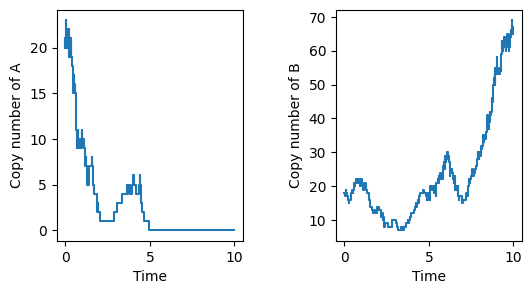

In [11]:
data_dir = "../data"  # relative to examples/ folder
os.makedirs(data_dir, exist_ok=True)

# Generate trajectory for CRN1
time_list1, state_list1 = generate_single_trajectory(
    rn1,
    CRN1_parameter_values,
    species_names,
    finalTime=10,   # adjust as needed
    minVal=15,
    maxVal=25,
    seed=42          # for reproducibility
)

#A = 25
#B = 15
trajectory_file1 = os.path.join(data_dir, "example4_trajectory.json")
save_trajectory(time_list1, state_list1, filename=trajectory_file1)
print(f"CRN1 trajectory saved to {trajectory_file1}")

In [12]:
# Parse trajectories for CRN1
print("Parsing trajectory for CRN1")
unique_states1, jump_counts1, waiting_times1, propensities1 = parse_trajectory(
    state_list1,time_list1,reactant_matrix,unique_changes,compatible_reactions,verbose=True)
print("---------")

# Print basic summary
print("Finished parsing trajectories. Summary:")
print(f"CRN1: {len(unique_states1)} unique states observed")

Parsing trajectory for CRN1
Tracking 18 unique stoichiometric changes.
Trajectory length: 490 timepoints. Iterating to len-2 to avoid final non-jump.
Finished parsing trajectory. Observed 161 unique states.
---------
Finished parsing trajectories. Summary:
CRN1: 161 unique states observed


In [14]:
# Local Likelihood Exploration for CRN1

pos_indices, pos_deltaX = get_positive_deltaX_indices_and_values(jump_counts1, unique_changes)

i = 0;

indexToCheck = pos_indices[i]
deltaXToCheck = pos_deltaX[i]

#Extract the local data for the desired stochiometric change.
(local_counts1, local_waiting_times1, local_propensities1, selected_deltaX) = extract_local_data(
    jump_counts1, waiting_times1, propensities1, unique_changes, 
    index=indexToCheck, deltaX=deltaXToCheck, verbose=False)

#Extract the Local True Theta for the unique stochiometric change
localTheta1 = trueTheta1[compatible_reactions[selected_deltaX]]

# Plot log-likelihood along alpha interpolation between localTheta1 and localTheta2
alphas, ll_values, max_ll, best_alpha, best_theta = plot_likelihood_vs_theta_interpolation(
    local_counts1,
    local_waiting_times1,
    local_propensities1,
    theta1=localTheta1,
    num_points=50,
    title='CRN1: Log Likelihood vs Theta Interpolation (alpha)'
)

State 0: positive indices = [ 2  5 11], counts = [1 1 2]
State 1: positive indices = [0 2], counts = [1 1]
State 2: positive indices = [ 5 11], counts = [1 1]
State 3: positive indices = [ 0  2 11], counts = [1 2 2]
State 4: positive indices = [11], counts = [2]
State 5: positive indices = [2], counts = [1]
State 6: positive indices = [5], counts = [1]
State 7: positive indices = [ 2  5 11], counts = [2 1 1]
State 8: positive indices = [ 2 11], counts = [1 1]
State 9: positive indices = [ 2 11], counts = [1 1]
State 10: positive indices = [11], counts = [4]
State 11: positive indices = [ 2 11], counts = [2 3]
State 12: positive indices = [0 2 5], counts = [1 1 1]
State 13: positive indices = [2], counts = [1]
State 14: positive indices = [2], counts = [1]
State 15: positive indices = [0], counts = [1]
State 16: positive indices = [0], counts = [1]
State 17: positive indices = [0], counts = [1]
State 18: positive indices = [11], counts = [1]
State 19: positive indices = [11], counts = [

TypeError: plot_likelihood_vs_theta_interpolation() missing 1 required positional argument: 'theta2'

State 0: positive indices = [ 6 12], counts = [46 47]
State 1: positive indices = [12], counts = [46]
State 2: positive indices = [6], counts = [47]
	Length of unique_changes: 18

All positive indices set across all states (unsorted): {12, 6}
Sorted positive indices: [6, 12]
Corresponding ΔX values: [(1, -1), (-1, 1)]

✅ All states processed successfully — no empty propensities, consistent lengths, no negative counts, all waiting times valid.
Theta1 = [1. 0. 0.]
Theta2 = [0. 2. 1.]
Maximum Log-Likelihood = -74.47392849881118
Best Alpha = 0.0
Best Theta = [0. 2. 1.]


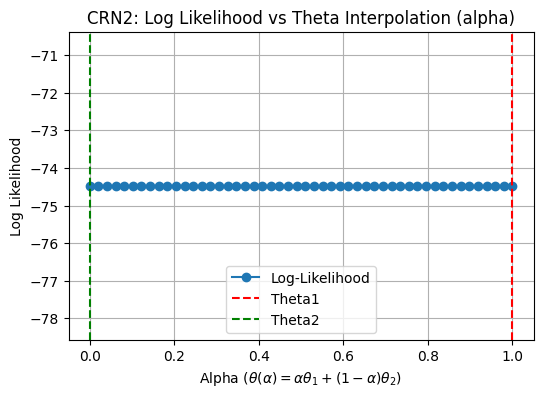

In [8]:
# Local Likelihood Exploration for CRN2

pos_indices, pos_deltaX = get_positive_deltaX_indices_and_values(jump_counts1, unique_changes)

i = 0;

indexToCheck = pos_indices[i]
deltaXToCheck = pos_deltaX[i]

#Extract the local data for the desired stochiometric change.
(local_counts1, local_waiting_times1, local_propensities1, selected_deltaX) = extract_local_data(
    jump_counts1, waiting_times1, propensities1, unique_changes, 
    index=indexToCheck, deltaX=deltaXToCheck, verbose=False)

#Extract the Local True Theta for the unique stochiometric change
localTheta1 = trueTheta1[compatible_reactions[selected_deltaX]]
localTheta2 = trueTheta2[compatible_reactions[selected_deltaX]]

# Plot log-likelihood along alpha interpolation between localTheta1 and localTheta2
alphas, ll_values, max_ll, best_alpha, best_theta = plot_likelihood_vs_theta_interpolation(
    local_counts1,
    local_waiting_times1,
    local_propensities1,
    theta1=localTheta1,
    theta2=localTheta2,
    num_points=50,
    title='CRN2: Log Likelihood vs Theta Interpolation (alpha)'
)

In [ ]:
# Ensure the results directory exists
results_dir = "../results/example4/CRN1SparsityMCMCLongerChain"
os.makedirs(results_dir, exist_ok=True)

## Debugging Parameters
runOnlyHigherDim        = False   # Only try to run cases that have >=2 variables
runOnlyOneHigherDimCase = False  # Only run one case with >=2 variables for debugging

## MCMC parameters
NIterates = 500_000
Burnin    = 50_000
Thinout   = 100

jump_counts    = jump_counts1
waiting_times  = waiting_times1
propensities   = propensities1
unique_changes = unique_changes
trueTheta      = trueTheta1

# Loop over all unique stoichiometric changes
for index, deltaX in enumerate(unique_changes):
    
    print(f"\nProcessing Index: {index}, Stoichiometric Change: {deltaX}")

    # Extract local data for this stoichiometric change
    (local_counts, local_waiting_times, local_propensities, selected_deltaX) = extract_local_data(
        jump_counts, waiting_times, propensities, unique_changes, 
        index=index, deltaX=deltaX, verbose=True
    )

    # Extract local true theta
    localTheta = trueTheta[compatible_reactions[selected_deltaX]]
    num_reactions = len(localTheta)

    # Skip low-dimensional cases if debugging
    if num_reactions < 2 and runOnlyHigherDim:
        print(f"🚫 Index {index} skipped: only {num_reactions} reaction(s) — needs at least 2 to run MCMC.")
        continue

    # Compute 2-norm
    norm_theta = np.linalg.norm(localTheta, ord=2)
    print(f"Local True Theta: {localTheta} (Norm: {norm_theta:.4f})")

    # Compute likelihood for true theta
    likeTrue = local_log_likelihood(local_counts, local_waiting_times, local_propensities, localTheta)
    print(f"True Likelihood = {likeTrue}")

    total_count = sum(local_counts.values())
    print(f"Total Count = {total_count}")

    # Initialize theta for MCMC
    a, b = 0.001, 2.0
    theta_init = np.random.uniform(a, b, size=localTheta.shape)
    likeInit = local_log_likelihood(local_counts, local_waiting_times, local_propensities, theta_init)

    # Run adaptive MCMC only if norm is significant
    if norm_theta > 0.01:
        print(f"Running Adaptive MCMC with spike-and-slab prior...")
        
        filtered_reactions = [reaction_names[i] for i in compatible_reactions[selected_deltaX]]
        print(f"Reaction Names = {filtered_reactions}")

        AdaptiveThetaChain = adaptive_mcmc_spike_slab(
            local_counts, local_waiting_times, local_propensities,
            theta_init, trueTheta, num_iterations=NIterates,
            alpha=2, beta=0.25, pi=0.70, burn_in=Burnin, adapt_every_n=10
        )

        # Define filenames
        filenameKDE = os.path.join(results_dir, f"AdaptiveMCMC_plot_Index_{index}_TotalCount_{total_count}_kde.png")
        filenameChain = os.path.join(results_dir, f"AdaptiveMCMC_plot_Index_{index}_TotalCount_{total_count}_chain.png")
        filenamePosterior = os.path.join(results_dir, f"AdaptiveMCMC_plot_Index_{index}_TotalCount_{total_count}_posterior.png")

        # Plotting
        plot_mcmc_samples(AdaptiveThetaChain, localTheta, epsilon=1e-5, burnin=Burnin, thinout=Thinout, filename=filenameKDE)
        plot_mcmc_chain(AdaptiveThetaChain, filename=filenameChain)
        if num_reactions >= 2:
            calc_network_posteriors(AdaptiveThetaChain, epsilon=1e-5, prob_cutoff=0.05, burnin=Burnin, thinout=Thinout)
            plot_network_and_parameter_posteriors(AdaptiveThetaChain, localTheta, epsilon=1e-5,
                                                 prob_cutoff=0.05, burnin=Burnin, thinout=Thinout, filename=filenamePosterior)

        # Summary statistics to Excel
        chains = [AdaptiveThetaChain]
        labels = ["Adaptive Spike & Slab"]
        summarize_chains(chains, localTheta, labels,
                         results_dir=results_dir, filename="mcmc_summary.xlsx",
                         burnin=Burnin, thinout=Thinout, alpha_ci=0.05, epsilon=1e-3,
                         run_index=index, count=total_count)

        print(f"MCMC completed for index {index}.")

        if (num_reactions > 1) and runOnlyOneHigherDimCase:
            break

    else:
        print(f"Skipping MCMC for index {index}: norm too small ({norm_theta:.4f}).")

    print("**********")



Processing Index: 0, Stoichiometric Change: (0, 1)
Extracting local data for stoichiometric change [0, 1] at index 0
✅ All states processed successfully — no empty propensities, consistent lengths, no negative counts, all waiting times valid.
Local data extraction complete. 161 states processed.
Local True Theta: [0.  0.8 0. ] (Norm: 0.8000)
True Likelihood = 507.49871657399297
Total Count = 220
Running Adaptive MCMC with spike-and-slab prior...
Reaction Names = ['Empty_to_B:', 'B_to_2B:', 'A_to_A+B:']
Iteration 10000: Accept Rate = 0.467, Theta = [0.         0.96940356 0.        ]
Iteration 20000: Accept Rate = 0.473, Theta = [0.         1.10033899 0.        ]
Iteration 30000: Accept Rate = 0.475, Theta = [0.         0.88711086 0.        ]
Iteration 40000: Accept Rate = 0.475, Theta = [0.         1.00424546 0.        ]
Iteration 50000: Accept Rate = 0.475, Theta = [0.         0.98730714 0.        ]
Iteration 60000: Accept Rate = 0.438, Theta = [0.         0.97555478 0.        ]
Itera

In [10]:
from scipy.optimize import minimize

# ============================
# Configuration
# ============================

results_dir = "../results/example1/CRN1_L1Only"
os.makedirs(results_dir, exist_ok=True)

runOnlyHigherDim        = True
runOnlyOneHigherDimCase = False

# Lambda sweep
lambdas = np.logspace(-4, 2, 50)

# Data aliases
jump_counts    = jump_counts1
waiting_times  = waiting_times1
propensities   = propensities1
unique_changes = unique_changes
trueTheta      = trueTheta1

# ============================
# Loop over stoichiometric changes
# ============================

for index, deltaX in enumerate(unique_changes):

    print(f"\nProcessing Index: {index}, Stoichiometric Change: {deltaX}")

    # ---- Extract local data ----
    (local_counts,
     local_waiting_times,
     local_propensities,
     selected_deltaX) = extract_local_data(
        jump_counts,
        waiting_times,
        propensities,
        unique_changes,
        index=index,
        deltaX=deltaX,
        verbose=True
    )

    # ---- Extract local true theta ----
    localTheta = trueTheta[compatible_reactions[selected_deltaX]]
    num_reactions = len(localTheta)

    if num_reactions < 2 and runOnlyHigherDim:
        print(f"🚫 Skipping index {index}: only {num_reactions} reaction(s)")
        continue

    norm_theta = np.linalg.norm(localTheta, ord=2)
    print(f"Local True Theta: {localTheta} (Norm: {norm_theta:.4f})")

    likeTrue = local_log_likelihood(
        local_counts,
        local_waiting_times,
        local_propensities,
        localTheta
    )
    print(f"True Log-Likelihood = {likeTrue}")

    total_count = sum(local_counts.values())
    print(f"Total Count = {total_count}")

    # Skip if no observed jumps
    if total_count == 0:
        print(f"⚠️ Skipping index {index}: no observed jumps for this stoichiometric change")
        continue
    
    # ---- Initialize theta ----
    a, b = 0.001, 2.0
    theta_init = np.random.uniform(a, b, size=localTheta.shape)

    likeInit = local_log_likelihood(
        local_counts,
        local_waiting_times,
        local_propensities,
        theta_init
    )
    print(f"Initial Log-Likelihood = {likeInit}")

    # ============================
    # L1 PATH OPTIMIZATION
    # ============================

    lams, theta_path, obj_values = run_l1_path(
        local_counts,
        local_waiting_times,
        local_propensities,
        theta_init,
        lambdas
    )

    # Reaction labels (optional but very helpful)
    reaction_labels = [
        reaction_names[i]
        for i in compatible_reactions[selected_deltaX]
    ]

    # ============================
    # Plot and save
    # ============================

    plot_l1_path(
    lams,
    theta_path,
    obj_values,
    results_dir,
    index,
    reaction_names=reaction_labels,
    true_theta=localTheta
    )


Processing Index: 0, Stoichiometric Change: (0, 1)
Extracting local data for stoichiometric change [0, 1] at index 0
✅ All states processed successfully — no empty propensities, consistent lengths, no negative counts, all waiting times valid.
Local data extraction complete. 3 states processed.
Local True Theta: [0. 0. 0.] (Norm: 0.0000)
True Log-Likelihood = 0
Total Count = 0
⚠️ Skipping index 0: no observed jumps for this stoichiometric change

Processing Index: 1, Stoichiometric Change: (0, 2)
Extracting local data for stoichiometric change [0, 2] at index 1
✅ All states processed successfully — no empty propensities, consistent lengths, no negative counts, all waiting times valid.
Local data extraction complete. 3 states processed.
🚫 Skipping index 1: only 1 reaction(s)

Processing Index: 2, Stoichiometric Change: (1, 0)
Extracting local data for stoichiometric change [1, 0] at index 2
✅ All states processed successfully — no empty propensities, consistent lengths, no negative coun

/Users/suzannesindi/.local/lib/python3.12/site-packages/scipy/optimize/_numdiff.py:590: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0



Processing Index: 7, Stoichiometric Change: (2, -1)
Extracting local data for stoichiometric change [2, -1] at index 7
✅ All states processed successfully — no empty propensities, consistent lengths, no negative counts, all waiting times valid.
Local data extraction complete. 3 states processed.
🚫 Skipping index 7: only 1 reaction(s)

Processing Index: 8, Stoichiometric Change: (0, -2)
Extracting local data for stoichiometric change [0, -2] at index 8
✅ All states processed successfully — no empty propensities, consistent lengths, no negative counts, all waiting times valid.
Local data extraction complete. 3 states processed.
🚫 Skipping index 8: only 1 reaction(s)

Processing Index: 9, Stoichiometric Change: (1, -2)
Extracting local data for stoichiometric change [1, -2] at index 9
✅ All states processed successfully — no empty propensities, consistent lengths, no negative counts, all waiting times valid.
Local data extraction complete. 3 states processed.
🚫 Skipping index 9: only 1 r

In [ ]:
# Ensure the results directory exists
results_dir = "../results/example1/CRN2"
os.makedirs(results_dir, exist_ok=True)

## Debugging Parameters
runOnlyHigherDim        = False   # Only try to run cases that have >=2 variables
runOnlyOneHigherDimCase = False  # Only run one case with >=2 variables for debugging

## MCMC parameters
NIterates = 500_000
Burnin    = 50_000
Thinout   = 100

jump_counts    = jump_counts2
waiting_times  = waiting_times2
propensities   = propensities2
unique_changes = unique_changes
trueTheta      = trueTheta2

# Loop over all unique stoichiometric changes
for index, deltaX in enumerate(unique_changes):
    
    print(f"\nProcessing Index: {index}, Stoichiometric Change: {deltaX}")

    # Extract local data for this stoichiometric change
    (local_counts, local_waiting_times, local_propensities, selected_deltaX) = extract_local_data(
        jump_counts, waiting_times, propensities, unique_changes, 
        index=index, deltaX=deltaX, verbose=True
    )

    # Extract local true theta
    localTheta = trueTheta[compatible_reactions[selected_deltaX]]
    num_reactions = len(localTheta)

    # Skip low-dimensional cases if debugging
    if num_reactions < 2 and runOnlyHigherDim:
        print(f"🚫 Index {index} skipped: only {num_reactions} reaction(s) — needs at least 2 to run MCMC.")
        continue

    # Compute 2-norm
    norm_theta = np.linalg.norm(localTheta, ord=2)
    print(f"Local True Theta: {localTheta} (Norm: {norm_theta:.4f})")

    # Compute likelihood for true theta
    likeTrue = local_log_likelihood(local_counts, local_waiting_times, local_propensities, localTheta)
    print(f"True Likelihood = {likeTrue}")

    total_count = sum(local_counts.values())
    print(f"Total Count = {total_count}")

    # Initialize theta for MCMC
    a, b = 0.001, 2.0
    theta_init = np.random.uniform(a, b, size=localTheta.shape)
    likeInit = local_log_likelihood(local_counts, local_waiting_times, local_propensities, theta_init)

    # Run adaptive MCMC only if norm is significant
    if norm_theta > 0.01:
        print(f"Running Adaptive MCMC with spike-and-slab prior...")
        
        filtered_reactions = [reaction_names[i] for i in compatible_reactions[selected_deltaX]]
        print(f"Reaction Names = {filtered_reactions}")

        AdaptiveThetaChain = adaptive_mcmc_spike_slab(
            local_counts, local_waiting_times, local_propensities,
            theta_init, trueTheta, num_iterations=NIterates,
            alpha=2, beta=0.25, pi=0.75, burn_in=Burnin, adapt_every_n=10
        )

        # Define filenames
        filenameKDE = os.path.join(results_dir, f"AdaptiveMCMC_plot_Index_{index}_TotalCount_{total_count}_kde.png")
        filenameChain = os.path.join(results_dir, f"AdaptiveMCMC_plot_Index_{index}_TotalCount_{total_count}_chain.png")
        filenamePosterior = os.path.join(results_dir, f"AdaptiveMCMC_plot_Index_{index}_TotalCount_{total_count}_posterior.png")

        # Plotting
        plot_mcmc_samples(AdaptiveThetaChain, localTheta, epsilon=1e-5, burnin=Burnin, thinout=Thinout, filename=filenameKDE)
        plot_mcmc_chain(AdaptiveThetaChain, filename=filenameChain)
        if num_reactions >= 2:
            calc_network_posteriors(AdaptiveThetaChain, epsilon=1e-5, prob_cutoff=0.05, burnin=Burnin, thinout=Thinout)
            plot_network_and_parameter_posteriors(AdaptiveThetaChain, localTheta, epsilon=1e-5,
                                                 prob_cutoff=0.05, burnin=Burnin, thinout=Thinout, filename=filenamePosterior)

        # Summary statistics to Excel
        chains = [AdaptiveThetaChain]
        labels = ["Adaptive Spike & Slab"]
        summarize_chains(chains, localTheta, labels,
                         results_dir=results_dir, filename="mcmc_summary.xlsx",
                         burnin=Burnin, thinout=Thinout, alpha_ci=0.05, epsilon=1e-3,
                         run_index=index, count=total_count)

        print(f"MCMC completed for index {index}.")

        if (num_reactions > 1) and runOnlyOneHigherDimCase:
            break

    else:
        print(f"Skipping MCMC for index {index}: norm too small ({norm_theta:.4f}).")

    print("**********")
